## Import data (x,y,z)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# 1. Bestanden ophalen
good_paths = glob.glob("data/1_*/**/Accelerometer.csv", recursive=True)
if not good_paths:
    good_paths = glob.glob("data/1_*/Accelerometer.csv")

bad_paths = glob.glob("data/2_*/**/Accelerometer.csv", recursive=True)
if not bad_paths:
    bad_paths = glob.glob("data/2_*/Accelerometer.csv")

## 2. Cut and Synchronise Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

def trim_to_30s(df):
    """Trims dataframe symmetrically to a duration of 30 seconds."""
    start_time = df['seconds_elapsed'].min()
    end_time = df['seconds_elapsed'].max()
    total_duration = end_time - start_time
    
    if total_duration > 30:
        trim_amount = (total_duration - 30) / 2
        new_start = start_time + trim_amount
        new_end = end_time - trim_amount
        
        # Filter rows within the 30-second window and reset elapsed time from 0
        df_trimmed = df[(df['seconds_elapsed'] >= new_start) & (df['seconds_elapsed'] <= new_end)].copy()
        df_trimmed['seconds_elapsed'] = df_trimmed['seconds_elapsed'] - new_start
        return df_trimmed
    return df

# Process and trim all discovered good road recordings dynamically
good_roads_trimmed = {}
for path in good_paths:
    key = path.split(os.sep)[-2]
    df = pd.read_csv(path)
    good_roads_trimmed[key] = trim_to_30s(df)

# Process and trim all discovered bad road recordings dynamically
bad_roads_trimmed = {}
for path in bad_paths:
    key = path.split(os.sep)[-2]
    df = pd.read_csv(path)
    bad_roads_trimmed[key] = trim_to_30s(df)

## Filteren and Windowing

In [3]:
import numpy as np
import pandas as pd
from scipy.signal import butter, lfilter
from scipy.stats import skew, kurtosis

# 1. Bandpass filter definitions
def butter_bandpass(lowcut, highcut, fs, order=4):
    """Design a Butterworth bandpass filter."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    """Apply the bandpass filter to a data array."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return lfilter(b, a, data)

# 2. Windowing and Feature Extraction function for X, Y, and Z
def create_windows_and_filter(df, window_size_sec=2.0, overlap=0.5, fs=100.0):
    """Apply sliding windows and extract statistical features from X, Y, and Z axes."""
    df_filtered = df.copy()
    
    # Filter toepassen op X, Y én Z
    axes = ['x', 'y', 'z']
    for axis in axes:
        df_filtered[f'{axis}_filtered'] = bandpass_filter(df[axis], lowcut=0.5, highcut=20.0, fs=fs)
    
    window_size_samples = int(window_size_sec * fs)
    step_size = int(window_size_samples * (1 - overlap))
    
    features_list = []
    
    for start in range(0, len(df_filtered) - window_size_samples, step_size):
        window = df_filtered.iloc[start:start + window_size_samples]
        
        feat = {}
        # Bereken kenmerken voor elke as afzonderlijk
        for axis in axes:
            sig = window[f'{axis}_filtered']
            feat[f'{axis}_mean'] = sig.mean()
            feat[f'{axis}_std'] = sig.std()
            feat[f'{axis}_rms'] = np.sqrt(np.mean(sig**2))
            feat[f'{axis}_peak_to_peak'] = sig.max() - sig.min()
            feat[f'{axis}_iqr'] = np.percentile(sig, 75) - np.percentile(sig, 25)
            feat[f'{axis}_skewness'] = skew(sig)
            feat[f'{axis}_kurtosis'] = kurtosis(sig)
            
        features_list.append(feat)
        
    return pd.DataFrame(features_list)

# --- GOEDE WEGEN VERWERKEN ---
all_good_windows = []
all_good_rides = []

for key, df_trimmed in good_roads_trimmed.items():
    feat_df = create_windows_and_filter(df_trimmed)
    
    # Bewaar alle individuele vensters
    feat_df['source'] = key
    feat_df['road_type'] = 'Good'
    all_good_windows.append(feat_df)
    
    # Bereken ook het gemiddelde voor de ride-level versie
    mean_feat = feat_df.mean(numeric_only=True).to_dict()
    mean_feat['source'] = key
    mean_feat['road_type'] = 'Good'
    all_good_rides.append(mean_feat)

features_good_windows = pd.concat(all_good_windows, ignore_index=True)
features_good_ride = pd.DataFrame(all_good_rides)


# --- SLECHTE WEGEN VERWERKEN ---
all_bad_windows = []
all_bad_rides = []

for key, df_trimmed in bad_roads_trimmed.items():
    feat_df = create_windows_and_filter(df_trimmed)
    
    # Bewaar alle individuele vensters
    feat_df['source'] = key
    feat_df['road_type'] = 'Bad'
    all_bad_windows.append(feat_df)
    
    # Bereken ook het gemiddelde voor de ride-level versie
    mean_feat = feat_df.mean(numeric_only=True).to_dict()
    mean_feat['source'] = key
    mean_feat['road_type'] = 'Bad'
    all_bad_rides.append(mean_feat)

features_bad_windows = pd.concat(all_bad_windows, ignore_index=True)
features_bad_ride = pd.DataFrame(all_bad_rides)


# 5. Samenvoegen tot beide master dataframes
window_level_features = pd.concat([features_good_windows, features_bad_windows], ignore_index=True)
ride_level_features = pd.concat([features_good_ride, features_bad_ride], ignore_index=True)

# 6. Print resultaten ter controle
print(f"Totaal aantal goede vensters: {len(features_good_windows)} | Goede ritten: {len(features_good_ride)}")
print(f"Totaal aantal slechte vensters: {len(features_bad_windows)} | Slechte ritten: {len(features_bad_ride)}")

Totaal aantal goede vensters: 232 | Goede ritten: 8
Totaal aantal slechte vensters: 203 | Slechte ritten: 7


## PCA



[RIDE-NIVEAU] Verklaarde variantie door PC1 en PC2: 71.55%
 - PC1: 47.6%
 - PC2: 23.9%


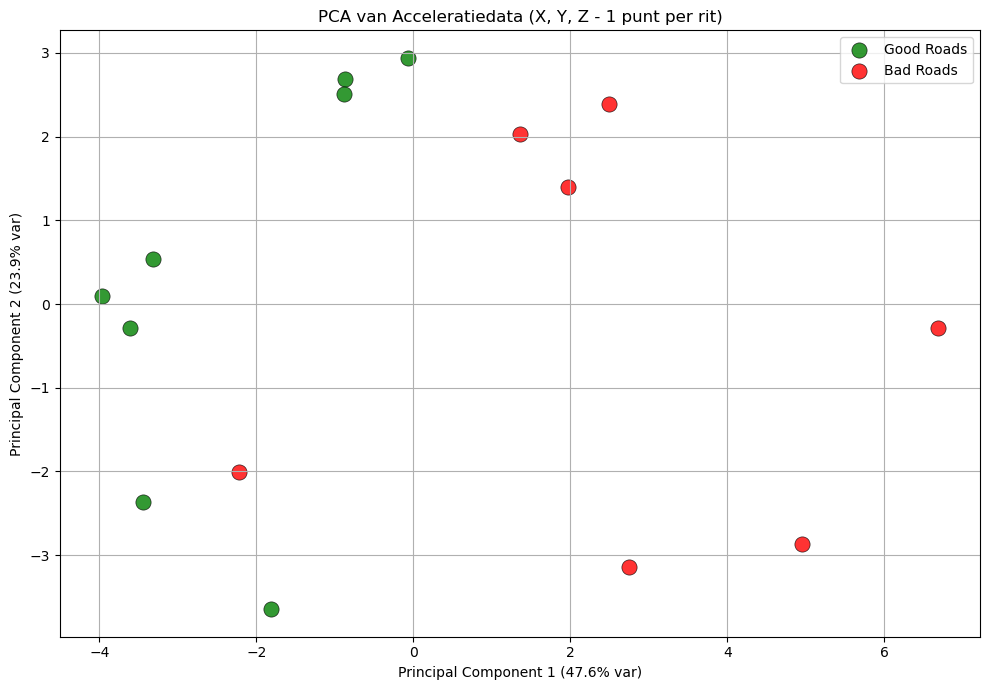


[WINDOW-NIVEAU] Verklaarde variantie door PC1 en PC2: 59.40%
 - PC1: 44.0%
 - PC2: 15.4%


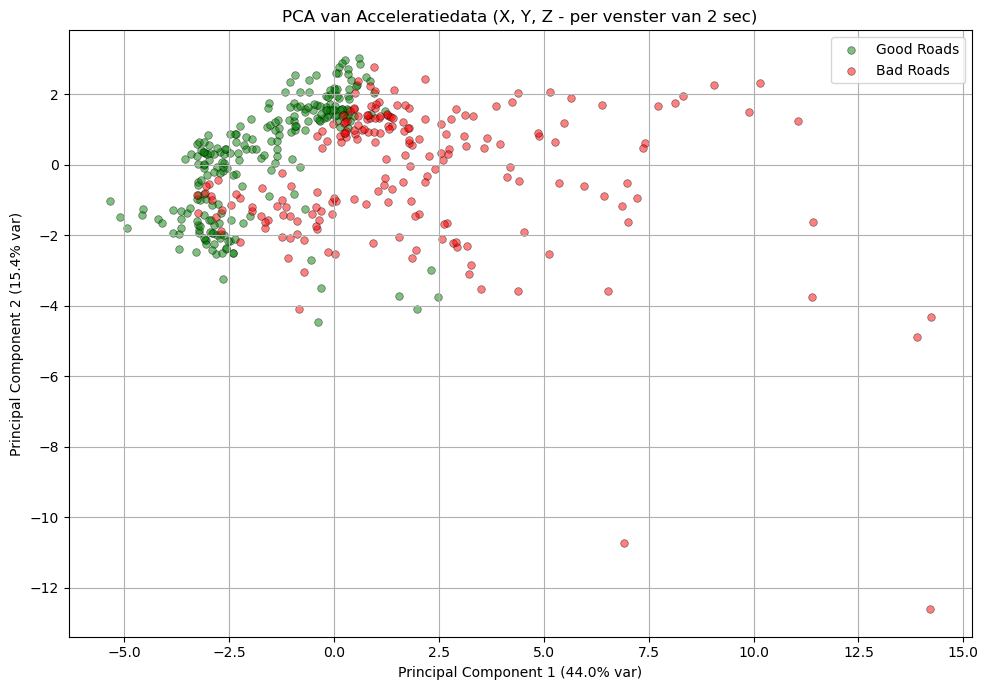

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# Loop door beide analyseniveau's heen zodat je direct allebei de plots krijgt
analysis_levels = ['ride', 'window']

for analysis_level in analysis_levels:
    
    # Selecteer de juiste dataset en instellingen op basis van het niveau
    if analysis_level == 'ride':
        target_df = ride_level_features
        title_suffix = "(X, Y, Z - 1 punt per rit)"
        point_size = 120
        point_alpha = 0.8
    else:
        target_df = window_level_features
        title_suffix = "(X, Y, Z - per venster van 2 sec)"
        point_size = 30
        point_alpha = 0.5

    # 1. Selecteer alleen de numerieke kenmerken (laat 'source' en 'road_type' buiten beschouwing)
    feature_cols = [col for col in target_df.columns if col not in ['source', 'road_type']]
    X = target_df[feature_cols]

    # 2. Normaliseer de data (essentieel bij PCA zodat alle features even zwaar tellen)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 3. Voer PCA uit (reduceer naar 2 componenten voor een 2D-plot)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X_scaled)

    # 4. Maak een tijdelijk DataFrame voor het plotten
    pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
    pca_df['road_type'] = target_df['road_type'].values
    pca_df['source'] = target_df['source'].values

    # Bereken hoeveel variantie de componenten verklaren
    explained_variance = pca.explained_variance_ratio_
    print(f"\n[{analysis_level.upper()}-NIVEAU] Verklaarde variantie door PC1 en PC2: {sum(explained_variance)*100:.2f}%")
    print(f" - PC1: {explained_variance[0]*100:.1f}%")
    print(f" - PC2: {explained_variance[1]*100:.1f}%")

    # 5. Visualiseer de resultaten in een 2D-scatter plot
    plt.figure(figsize=(10, 7))
    colors = {'Good': 'green', 'Bad': 'red'}

    for road_type, color in colors.items():
        subset = pca_df[pca_df['road_type'] == road_type]
        
        plt.scatter(
            subset['PC1'], subset['PC2'], 
            label=f"{road_type} Roads", color=color, 
            alpha=point_alpha, s=point_size, edgecolors='k', linewidths=0.5
        )

    plt.title(f"PCA van Acceleratiedata {title_suffix}")
    plt.xlabel(f"Principal Component 1 ({explained_variance[0]*100:.1f}% var)")
    plt.ylabel(f"Principal Component 2 ({explained_variance[1]*100:.1f}% var)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. DataFrame (window_level_features of ride_level_features)
df_ml = window_level_features.copy() 

# Maak de target-kolom aan (0 = Goed, 1 = Slecht)
if 'road_type' in df_ml.columns and df_ml['road_type'].dtype == 'object':
    df_ml['target'] = df_ml['road_type'].apply(lambda x: 0 if x in ['Good', 'Good Road'] else 1)

# 2. Selecteer automatisch alle numerieke kenmerken (inclusief X, Y, Z features)
# We sluiten 'source', 'road_type' en 'target' uit als features
feature_cols = [col for col in df_ml.columns if col not in ['source', 'road_type', 'target']]

X = df_ml[feature_cols]
y = df_ml['target']
groups = df_ml['source']

print(f"Originele data vorm (X) met alle features: {X.shape}")

#PC1 and PC2 gebruiken voor naive bayes en k-means

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca_array = pca.fit_transform(X_scaled)

# Dit is je nieuwe X-matrix die je direct kunt gebruiken voor Naive Bayes en K-Means!
X_pca = pd.DataFrame(X_pca_array, columns=['PC1', 'PC2'])

print(f"Nieuwe data vorm na PCA (X_pca): {X_pca.shape}")
print(f"Aantal unieke ritten (groups): {groups.nunique()}")

Originele data vorm (X) met alle features: (435, 21)
Nieuwe data vorm na PCA (X_pca): (435, 2)
Aantal unieke ritten (groups): 15


In [15]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. GroupKFold met 5 folds instellen
gkf = GroupKFold(n_splits=5)

# Haal de eerste fold op als standaard train/test split
train_idx, test_idx = next(gkf.split(X, y, groups))

# Splits de ruwe data en de targets op basis van de fold-indices
X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 2. Stap-voor-stap transformatie
# A. Schalen
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# B. PCA toepassen (reductie naar PC1 en PC2)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Omzetten naar DataFrames voor het gemak
X_train_pca_df = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=['PC1', 'PC2'])

# Controle-output
print(f"Aantal samples in Train set: {len(X_train_pca_df)} (Ritten in train: {groups.iloc[train_idx].nunique()})")
print(f"Aantal samples in Test set: {len(X_test_pca_df)} (Ritten in test: {groups.iloc[test_idx].nunique()})")
print(f"Verklaarde variantie door deze fold-PCA: {pca.explained_variance_ratio_sum() if hasattr(pca, 'explained_variance_ratio_sum') else sum(pca.explained_variance_ratio_)*100:.1f}%")

Aantal samples in Train set: 348 (Ritten in train: 12)
Aantal samples in Test set: 87 (Ritten in test: 3)
Verklaarde variantie door deze fold-PCA: 60.2%


In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_te, y_te, model_name="Model"):
    """Evalueer een getraind model en print de resultaten overzichtelijk."""
    y_pred = model.predict(X_te)
    
    acc = accuracy_score(y_te, y_pred)
    print(f"--- Evaluatie voor: {model_name} ---")
    print(f"Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_te, y_pred, target_names=['Good Road (0)', 'Bad Road (1)']))
    
    # Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    

--- Evaluatie voor: Naive Bayes (PCA) ---
Accuracy: 0.5057

Classification Report:
               precision    recall  f1-score   support

Good Road (0)       0.40      0.97      0.57        29
 Bad Road (1)       0.94      0.28      0.43        58

     accuracy                           0.51        87
    macro avg       0.67      0.62      0.50        87
 weighted avg       0.76      0.51      0.47        87



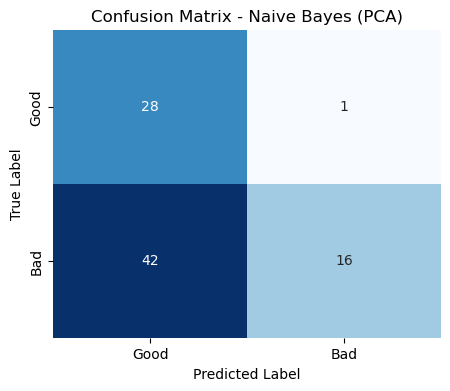

In [17]:
from sklearn.naive_bayes import GaussianNB

# 1. Initialiseer het Naive Bayes model
nb_model = GaussianNB()

# 2. Train het model op de PCA-getransformeerde trainingsdata (PC1 en PC2)
nb_model.fit(X_train_pca_df, y_train)

# 3. Evalueer het model met je evaluatiefunctie op de testdata
evaluate_model(nb_model, X_test_pca_df, y_test, model_name="Naive Bayes (PCA)")

K-Means clusters automatisch omgedraaid voor correcte matching met targets.
--- Evaluatie voor: K-Means Clustering (PCA) ---
Accuracy: 0.5402

Classification Report:
               precision    recall  f1-score   support

Good Road (0)       0.00      0.00      0.00        29
 Bad Road (1)       0.62      0.81      0.70        58

     accuracy                           0.54        87
    macro avg       0.31      0.41      0.35        87
 weighted avg       0.41      0.54      0.47        87



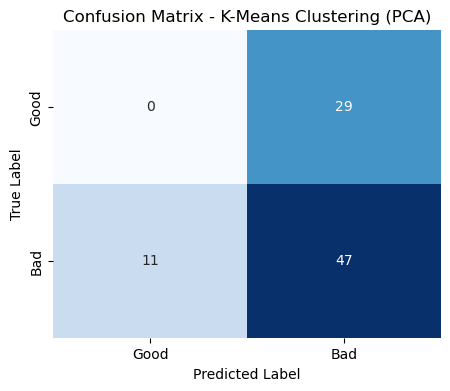

In [18]:
from sklearn.cluster import KMeans
import numpy as np

# 1. Initialiseer K-Means met 2 clusters (omdat we Good/Bad hebben)
# random_state zorgt ervoor dat je elke keer dezelfde clusters krijgt
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# 2. Fit K-Means op de PCA-trainingsdata (PC1 en PC2)
kmeans.fit(X_train_pca_df)

# 3. Voorspel de clusters voor de testdata
y_pred_kmeans_raw = kmeans.predict(X_test_pca_df)

# Omdat K-Means willekeurig cluster-ID's (0 of 1) toekent die niet 
# hoeven tematchen met onze target (0=Goed, 1=Slecht), controleren we de mapping:
# We kijken of we de labels moeten omdraaien voor een correcte evaluatie.
from sklearn.metrics import accuracy_score
acc_normal = accuracy_score(y_test, y_pred_kmeans_raw)
y_pred_kmeans_flipped = 1 - y_pred_kmeans_raw
acc_flipped = accuracy_score(y_test, y_pred_kmeans_flipped)

if acc_flipped > acc_normal:
    y_pred_kmeans = y_pred_kmeans_flipped
    print("K-Means clusters automatisch omgedraaid voor correcte matching met targets.")
else:
    y_pred_kmeans = y_pred_kmeans_raw

# Maak een tijdelijk object of wrapper zodat onze 'evaluate_model' functie ermee overweg kan
class KMeansWrapper:
    def __init__(self, preds):
        self.preds = preds
    def predict(self, X):
        return self.preds

kmeans_wrapped = KMeansWrapper(y_pred_kmeans)

# 4. Euvelueer K-Means met dezelfde vertrouwde evaluatiefunctie
evaluate_model(kmeans_wrapped, X_test_pca_df, y_test, model_name="K-Means Clustering (PCA)")